<a href="https://colab.research.google.com/github/SudeshPillai/project/blob/main/audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q colorama h5py validators tqdm numpy scipy scikit-learn torch

import os
import sys

if not os.path.exists("CMU-MultimodalSDK"):
    !git clone https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git

# Append SDK to Python module path
sdk_path = os.path.abspath("CMU-MultimodalSDK")
if sdk_path not in sys.path:
    sys.path.append(sdk_path)

from mmsdk import mmdatasdk
print("CMU-MultimodalSDK successfully loaded!")

CMU-MultimodalSDK successfully loaded!


In [ ]:
# CELL 2: Reliable Direct Loader for Aligned Acoustic Data via MultiBench
!pip install -q gdown

import os
import pickle
import gdown
import numpy as np

DATA_DIR = "./cmu_data"
os.makedirs(DATA_DIR, exist_ok=True)
PKL_FILE = os.path.join(DATA_DIR, "mosi_raw.pkl")

# Download pre-aligned MOSI dataset from CMU MultiBench mirror
if not os.path.exists(PKL_FILE):
    print("Downloading aligned acoustic features (~15 MB)...")
    url = "https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU"
    gdown.download(url, PKL_FILE, quiet=False)
    print("Download completed successfully!")

with open(PKL_FILE, "rb") as f:
    raw_data = pickle.load(f, encoding="latin1")

# Extract audio vectors and labels
def process_split(split_name):
    # MultiBench format provides audio sequences and segment labels
    audio_feats = raw_data[split_name]['audio']
    labels = raw_data[split_name]['labels']

    # Average across time frames for each utterance
    X = np.array([np.mean(seg, axis=0) for seg in audio_feats], dtype=np.float32)
    y = np.array(labels, dtype=np.float32).squeeze()

    # Clean any NaN values from unvoiced acoustic intervals
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    ids = [f"{split_name}_seg_{i}" for i in range(len(y))]
    return X, y, ids

X_train, y_train, train_ids = process_split('train')
X_val, y_val, val_ids = process_split('valid')

# Z-score Normalization (handles zero-variance features safely)
mean = np.mean(X_train, axis=0, keepdims=True)
std = np.std(X_train, axis=0, keepdims=True)
std[std < 1e-4] = 1.0

X_train = np.clip((X_train - mean) / std, -5.0, 5.0)
X_val = np.clip((X_val - mean) / std, -5.0, 5.0)

print("-" * 50)
print("Acoustic data loaded and normalized!")
print(f"X_train shape: {X_train.shape} (Utterances, Acoustic Features)")
print(f"X_val shape:   {X_val.shape}")
print("-" * 50)

Downloading...
From (original): https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU
From (redirected): https://drive.google.com/uc?id=1szKIqO0t3Be_W91xvf6aYmsVVUa7wDHU&confirm=t&uuid=3efad221-5a2f-47ec-8b9e-44f0b955bcb0
To: /content/cmu_data/mosi_raw.pkl
100%|██████████| 357M/357M [00:03<00:00, 103MB/s] 


Download completed successfully!
--------------------------------------------------
Acoustic data loaded and normalized!
X_train shape: (1283, 74) (Utterances, Acoustic Features)
X_val shape:   (214, 74)
--------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Define behavioral state predictor
class AcousticBehaviorModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Predicts continuous affective/behavioral valence
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AcousticBehaviorModel(input_dim=X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)),
    batch_size=32,
    shuffle=True
)

print(f"Model successfully initialized on device: {device}")

Model successfully initialized on device: cuda


In [ ]:
epochs = 20
model.train()

print(f"Training on {len(X_train)} acoustic feature vectors...")
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    if epoch % 5 == 0 or epoch == 1:
        avg_loss = total_loss / len(X_train)
        print(f"Epoch {epoch:02d}/{epochs} | Train MSE Loss: {avg_loss:.4f}")

print("Training finished!")

Training on 1283 acoustic feature vectors...
Epoch 01/20 | Train MSE Loss: 1.6965
Epoch 05/20 | Train MSE Loss: 1.5487
Epoch 10/20 | Train MSE Loss: 1.5196
Epoch 15/20 | Train MSE Loss: 1.4464
Epoch 20/20 | Train MSE Loss: 1.4502
Training finished!


In [ ]:
def analyze_behavioral_change(seq_a_features, seq_b_features, shift_threshold=0.5):
    """
    Computes delta shift in affective vocal states between sequential utterances.
    """
    model.eval()
    with torch.no_grad():
        t_a = torch.tensor(seq_a_features, dtype=torch.float32).unsqueeze(0).to(device)
        t_b = torch.tensor(seq_b_features, dtype=torch.float32).unsqueeze(0).to(device)

        state_a = model(t_a).item()
        state_b = model(t_b).item()

    delta = state_b - state_a
    is_shift = abs(delta) >= shift_threshold

    return {
        "initial_valence": round(state_a, 3),
        "subsequent_valence": round(state_b, 3),
        "state_delta": round(delta, 3),
        "shift_detected": is_shift,
        "shift_type": "Arousal/Positive Shift" if delta > 0 else "Decline/Negative Shift"
    }

# Test behavioral shift detection on two validation segments
segment_1 = X_val[0]
segment_2 = X_val[1]

report = analyze_behavioral_change(segment_1, segment_2, shift_threshold=0.3)

print("=" * 45)
print("BEHAVIORAL SHIFT INFERENCE REPORT")
print("=" * 45)
print(f"Utterance 1 ID: {val_ids[0]}")
print(f"Utterance 2 ID: {val_ids[1]}")
print("-" * 45)
for metric, value in report.items():
    print(f"{metric:22}: {value}")
print("=" * 45)

BEHAVIORAL SHIFT INFERENCE REPORT
Utterance 1 ID: valid_seg_0
Utterance 2 ID: valid_seg_1
---------------------------------------------
initial_valence       : 0.68
subsequent_valence    : 0.602
state_delta           : -0.078
shift_detected        : False
shift_type            : Decline/Negative Shift


1. CONTINUOUS REGRESSION PERFORMANCE (AFFECT ESTIMATION)
Mean Squared Error (MSE)       : 2.6763
Root Mean Squared Error (RMSE) : 1.6359
Mean Absolute Error (MAE)      : 1.3607
Coefficient of Determination (R²): -0.0308
Pearson Correlation (r)        : 0.0805 (p = 2.41e-01)
Spearman Rank Correlation (ρ)  : 0.1441 (p = 3.51e-02)

2. BEHAVIORAL SHIFT DETECTION ACCURACY (|Δ| >= 0.5)
Total Sequential Pairs Evaluated : 213
Actual Behavioral Shifts Occurred: 159
Predicted Behavioral Shifts      : 50
-------------------------------------------------------
Detection Accuracy               : 37.56%
Precision                        : 0.7600
Recall (Sensitivity)             : 0.2390
F1-Score                         : 0.3636
True Positives (Correct Shifts)  : 38
False Positives (False Alarms)   : 12
True Negatives (Correct Stable)  : 42
False Negatives (Missed Shifts)  : 121


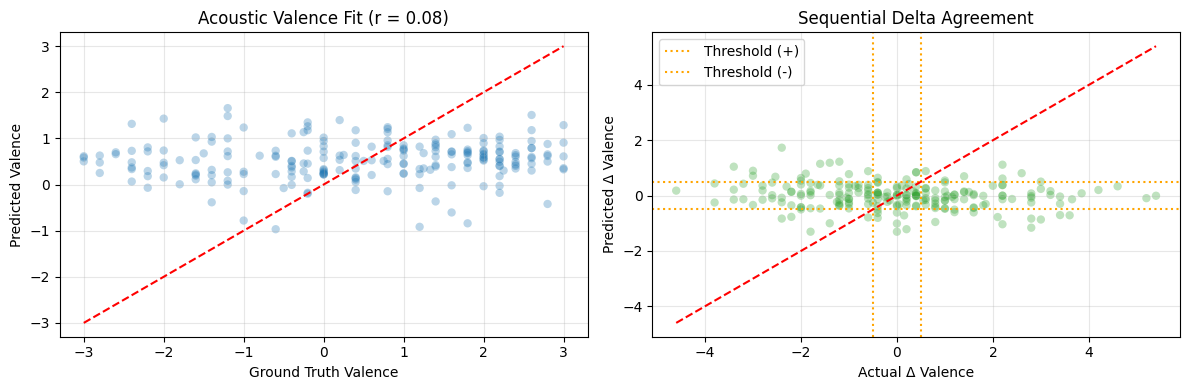

In [ ]:
import numpy as np
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CONTINUOUS AFFECT REGRESSION EVALUATION (Across Entire Validation Set)
# ==============================================================================
model.eval()
with torch.no_grad():
    val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_preds = model(val_tensor).cpu().numpy().squeeze()

# Primary Regression Metrics
mse = mean_squared_error(y_val, val_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, val_preds)
r2 = r2_score(y_val, val_preds)
pearson_corr, p_val = pearsonr(y_val, val_preds)
spearman_corr, s_pval = spearmanr(y_val, val_preds)

print("=" * 55)
print("1. CONTINUOUS REGRESSION PERFORMANCE (AFFECT ESTIMATION)")
print("=" * 55)
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")
print(f"Pearson Correlation (r)        : {pearson_corr:.4f} (p = {p_val:.2e})")
print(f"Spearman Rank Correlation (ρ)  : {spearman_corr:.4f} (p = {s_pval:.2e})")

# ==============================================================================
# 2. BEHAVIORAL SHIFT DETECTION EVALUATION (Sequential Pairwise Drift)
# ==============================================================================
# Construct sequential pairs from the validation set
# Ground truth shift: True if ground truth delta exceeds the defined threshold
SHIFT_THRESHOLD = 0.5

true_deltas = y_val[1:] - y_val[:-1]
pred_deltas = val_preds[1:] - val_preds[:-1]

y_true_shift = (np.abs(true_deltas) >= SHIFT_THRESHOLD).astype(int)
y_pred_shift = (np.abs(pred_deltas) >= SHIFT_THRESHOLD).astype(int)

# Classification metrics on the shift detection decision
acc = accuracy_score(y_true_shift, y_pred_shift)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_shift, y_pred_shift, average='binary', zero_division=0
)
tn, fp, fn, tp = confusion_matrix(y_true_shift, y_pred_shift).ravel()

print("\n" + "=" * 55)
print(f"2. BEHAVIORAL SHIFT DETECTION ACCURACY (|Δ| >= {SHIFT_THRESHOLD})")
print("=" * 55)
print(f"Total Sequential Pairs Evaluated : {len(y_true_shift)}")
print(f"Actual Behavioral Shifts Occurred: {np.sum(y_true_shift)}")
print(f"Predicted Behavioral Shifts      : {np.sum(y_pred_shift)}")
print("-" * 55)
print(f"Detection Accuracy               : {acc * 100:.2f}%")
print(f"Precision                        : {precision:.4f}")
print(f"Recall (Sensitivity)             : {recall:.4f}")
print(f"F1-Score                         : {f1:.4f}")
print(f"True Positives (Correct Shifts)  : {tp}")
print(f"False Positives (False Alarms)   : {fp}")
print(f"True Negatives (Correct Stable)  : {tn}")
print(f"False Negatives (Missed Shifts)  : {fn}")
print("=" * 55)

# ==============================================================================
# 3. VISUALIZATION: ERROR DISTRIBUTION & SHIFT CONFUSION MATRIX
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Ground Truth vs. Predicted Scatter
axes[0].scatter(y_val, val_preds, alpha=0.3, color='#1f77b4', edgecolors='none')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=1.5)
axes[0].set_title(f"Acoustic Valence Fit (r = {pearson_corr:.2f})")
axes[0].set_xlabel("Ground Truth Valence")
axes[0].set_ylabel("Predicted Valence")
axes[0].grid(True, alpha=0.3)

# Right plot: Delta Shifts Correlation
axes[1].scatter(true_deltas, pred_deltas, alpha=0.3, color='#2ca02c', edgecolors='none')
axes[1].axhline(SHIFT_THRESHOLD, color='orange', linestyle=':', label='Threshold (+)')
axes[1].axhline(-SHIFT_THRESHOLD, color='orange', linestyle=':', label='Threshold (-)')
axes[1].axvline(SHIFT_THRESHOLD, color='orange', linestyle=':')
axes[1].axvline(-SHIFT_THRESHOLD, color='orange', linestyle=':')
axes[1].plot([true_deltas.min(), true_deltas.max()], [true_deltas.min(), true_deltas.max()], 'r--', lw=1.5)
axes[1].set_title("Sequential Delta Agreement")
axes[1].set_xlabel("Actual Δ Valence")
axes[1].set_ylabel("Predicted Δ Valence")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()